# Phase 3: Classical ML Models (Comprehensive)
In this notebook, we will train a suite of models ranging from simple to state-of-the-art:
1. **Linear Regression** (Baseline)
2. **Random Forest** (Bagging Ensemble)
3. **XGBoost** (Boosting Ensemble)
4. **LightGBM** (Faster Boosting Ensemble)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.style.use('ggplot')

In [ ]:
# 1. Load Data
df = pd.read_csv('../data/processed/engineered_running_times.csv')

# 2. Prepare Features (X) and Target (y)
X = df.drop(columns=['run_time_in_seconds'])
y = df['run_time_in_seconds']

# 3. Train / Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Helper function to print metrics consistently
def print_metrics(model_name, y_true, y_pred):
    print(f"--- {model_name} Results ---")
    print(f"MAE:  {mean_absolute_error(y_true, y_pred):.2f} seconds")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.2f} seconds")
    print(f"R2:   {r2_score(y_true, y_pred):.4f}\n")

In [ ]:
# 4. Baseline Model: Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

print_metrics("Linear Regression", y_test, lr_preds)

--- Linear Regression Results ---
MAE:  36.64 seconds
RMSE: 60.98 seconds
R2:   0.7601



In [ ]:
# 5. Bagging Ensemble: Random Forest
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print_metrics("Random Forest", y_test, rf_preds)

--- Random Forest Results ---
MAE:  35.87 seconds
RMSE: 59.56 seconds
R2:   0.7711



In [ ]:
# 6. Boosting Ensemble: XGBoost
xgb_model = xgb.XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=6, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

print_metrics("XGBoost", y_test, xgb_preds)

--- XGBoost Results ---
MAE:  35.87 seconds
RMSE: 59.52 seconds
R2:   0.7715



In [ ]:
# 7. Faster Boosting Ensemble: LightGBM
lgb_model = lgb.LGBMRegressor(n_estimators=200, learning_rate=0.1, max_depth=6, random_state=42, n_jobs=-1)
lgb_model.fit(X_train, y_train)
lgb_preds = lgb_model.predict(X_test)

print_metrics("LightGBM", y_test, lgb_preds)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000964 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 403
[LightGBM] [Info] Number of data points in the train set: 160543, number of used features: 10
[LightGBM] [Info] Start training from score 188.342849
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
--- LightGBM Results ---
MAE:  35.79 seconds
RMSE: 59.40 seconds
R2:   0.7723



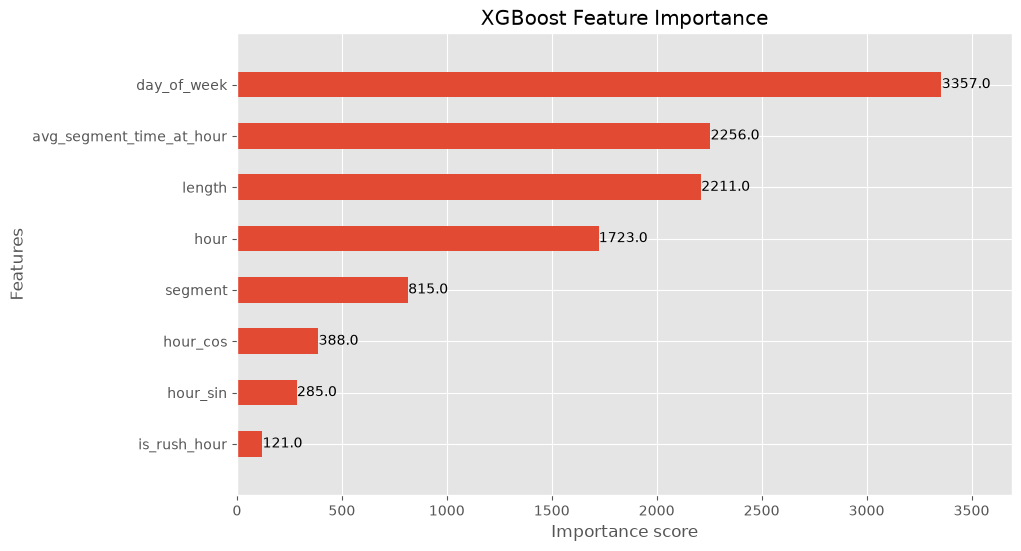

In [ ]:
# 8. Feature Importance Visualization (XGBoost)
plt.figure(figsize=(10, 6))
xgb.plot_importance(xgb_model, max_num_features=10, height=0.5, ax=plt.gca())
plt.title('XGBoost Feature Importance')
plt.show()